K-MEANS CLUSTERING PER PLAYERS

In [1]:
pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("player_kmeans_feature.csv")

print("Jumlah data:", df.shape)
df.head()

Jumlah data: (52, 18)


,user_id,username,total_sessions,total_completed,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,min_skill_score,best_skill_score,first_session_at,last_session_at,skill_category,activity_category
0,3257447993,Clamsxeny,85,14,16.47,199.02,7.40,2.60,0.5200,0.6407,0.6413,0.5688,0.0000,1.0000,2025-01-08 07:18:53.269172,2026-05-12 23:49:41,Pemain Menengah,Pemain Aktif
1,USER_45,Player_45,51,9,17.65,444.67,15.00,3.12,0.6235,0.6346,0.4682,0.5698,0.2897,0.9783,2025-01-08 08:12:07.165302,2026-05-03 03:53:55.204411,Pemain Menengah,Pemain Aktif
2,USER_16,Player_16,47,13,27.66,415.57,15.91,3.34,0.6681,0.5730,0.5037,0.5782,0.3012,0.8797,2025-01-12 04:56:48.529296,2026-04-28 14:16:30.013898,Pemain Menengah,Pemain Aktif
3,USER_23,Player_23,46,9,19.57,498.39,14.11,3.17,0.6348,0.6389,0.4272,0.5625,0.2717,0.9542,2025-01-04 02:21:30.013338,2026-05-09 03:38:12.041987,Pemain Menengah,Pemain Aktif
4,USER_22,Player_22,45,7,15.56,446.51,16.42,3.07,0.6133,0.5979,0.4466,0.5508,0.2309,0.9281,2025-01-05 09:02:33.151517,2026-05-03 05:40:50.505588,Pemain Menengah,Pemain Aktif


CEK UKURAN DATA

In [5]:
df.shape
df.columns

Index(['user_id', 'username', 'total_sessions', 'total_completed',
       'completion_rate', 'avg_time_spent', 'avg_death_count',
       'avg_max_checkpoint', 'avg_progress_score', 'avg_survival_score',
       'avg_efficiency_score', 'avg_skill_score', 'min_skill_score',
       'best_skill_score', 'first_session_at', 'last_session_at',
       'skill_category', 'activity_category'],
      dtype='object')

CEK INFORMASI DATA

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               52 non-null     object 
 1   username              52 non-null     object 
 2   total_sessions        52 non-null     int64  
 3   total_completed       52 non-null     int64  
 4   completion_rate       52 non-null     float64
 5   avg_time_spent        52 non-null     float64
 6   avg_death_count       52 non-null     float64
 7   avg_max_checkpoint    52 non-null     float64
 8   avg_progress_score    52 non-null     float64
 9   avg_survival_score    52 non-null     float64
 10  avg_efficiency_score  52 non-null     float64
 11  avg_skill_score       52 non-null     float64
 12  min_skill_score       52 non-null     float64
 13  best_skill_score      52 non-null     float64
 14  first_session_at      52 non-null     object 
 15  last_session_at       52 

CEK MISSING VALUE

In [7]:
df.isnull().sum()

,0
user_id,0
username,0
total_sessions,0
total_completed,0
completion_rate,0
avg_time_spent,0
avg_death_count,0
avg_max_checkpoint,0
avg_progress_score,0
avg_survival_score,0


Pilih Fitur numerik untuk K-Means

In [9]:
features = [
    "total_sessions",
    "completion_rate",
    "avg_time_spent",
    "avg_death_count",
    "avg_max_checkpoint",
    "avg_progress_score",
    "avg_survival_score",
    "avg_efficiency_score",
    "avg_skill_score",
    "best_skill_score"
]

X = df[features]

X.head()

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score
0,85,16.47,199.02,7.40,2.60,0.5200,0.6407,0.6413,0.5688,1.0000
1,51,17.65,444.67,15.00,3.12,0.6235,0.6346,0.4682,0.5698,0.9783
2,47,27.66,415.57,15.91,3.34,0.6681,0.5730,0.5037,0.5782,0.8797
3,46,19.57,498.39,14.11,3.17,0.6348,0.6389,0.4272,0.5625,0.9542
4,45,15.56,446.51,16.42,3.07,0.6133,0.5979,0.4466,0.5508,0.9281


CEK STATISTIK FITUR

In [10]:
X.describe()

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,37.576923,18.504038,432.016538,15.716923,3.084423,0.616800,0.579269,0.486060,0.555865,0.875542
std,9.092868,6.773290,54.373087,2.295761,0.228888,0.045626,0.049438,0.052400,0.026009,0.058055
min,21.000000,4.000000,199.020000,7.400000,2.570000,0.514300,0.434600,0.305200,0.475300,0.720900
25%,32.750000,14.050000,411.202500,14.342500,2.905000,0.580425,0.551075,0.463675,0.541325,0.838650
50%,37.000000,18.185000,434.090000,15.855000,3.095000,0.618800,0.573150,0.491700,0.555450,0.876400
75%,40.250000,20.820000,453.755000,16.642500,3.232500,0.646400,0.610325,0.506825,0.568500,0.915100
max,85.000000,37.930000,605.690000,21.120000,3.690000,0.737900,0.677800,0.641300,0.621600,1.000000


SCALING DATA

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

X_scaled_df.head()

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score
0,5.266298,-0.303233,-4.326952,-3.658074,-2.137065,-2.142280,1.254716,2.991504,0.502163,2.164688
1,1.490623,-0.127319,0.234986,-0.315328,0.156950,0.148278,1.130124,-0.344157,0.540986,1.787261
2,1.046426,1.364963,-0.305427,0.084922,1.127495,1.135320,-0.128048,0.339933,0.867101,0.072315
3,0.935377,0.158913,1.232614,-0.706781,0.377528,0.398358,1.217951,-1.134233,0.257577,1.368091
4,0.824327,-0.438895,0.269156,0.309238,-0.063628,-0.077458,0.380531,-0.760392,-0.196654,0.914134


ELBOW METHOD

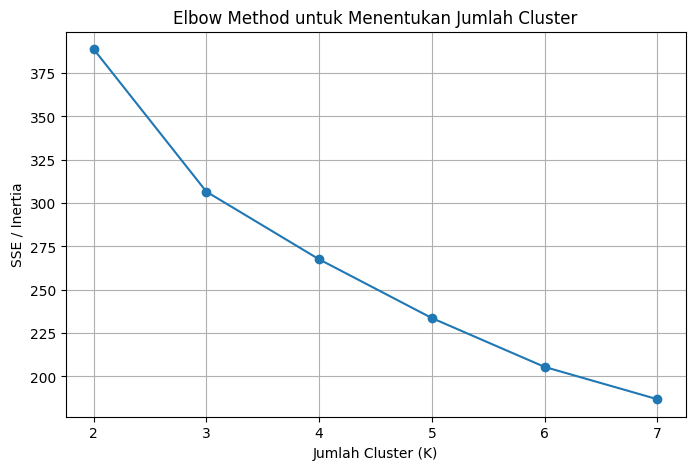

In [12]:
sse = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, sse, marker='o')
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("SSE / Inertia")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

Silhouette Score

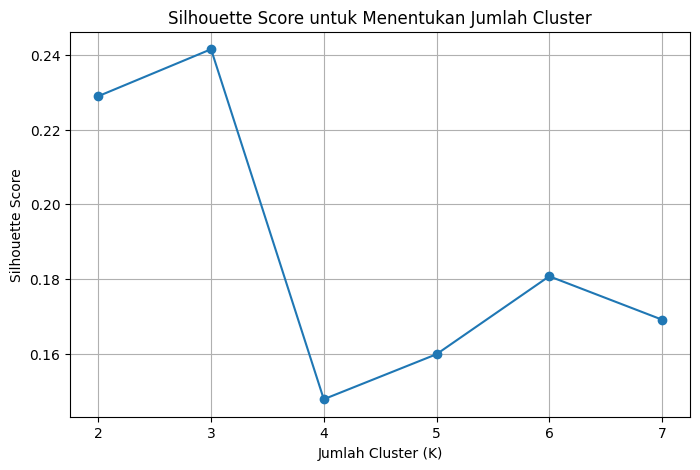

,K,Silhouette Score,SSE
0,2,0.228967,388.768018
1,3,0.241543,306.569229
2,4,0.147760,267.546233
3,5,0.159819,233.657279
4,6,0.180705,205.478253
5,7,0.169087,186.846992


In [13]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title("Silhouette Score untuk Menentukan Jumlah Cluster")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

silhouette_df = pd.DataFrame({
    "K": list(K_range),
    "Silhouette Score": silhouette_scores,
    "SSE": sse
})

silhouette_df

Training K-Means dengan K=3

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df["cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,user_id,username,total_sessions,total_completed,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,min_skill_score,best_skill_score,first_session_at,last_session_at,skill_category,activity_category,cluster
0,3257447993,Clamsxeny,85,14,16.47,199.02,7.40,2.60,0.5200,0.6407,0.6413,0.5688,0.0000,1.0000,2025-01-08 07:18:53.269172,2026-05-12 23:49:41,Pemain Menengah,Pemain Aktif,2
1,USER_45,Player_45,51,9,17.65,444.67,15.00,3.12,0.6235,0.6346,0.4682,0.5698,0.2897,0.9783,2025-01-08 08:12:07.165302,2026-05-03 03:53:55.204411,Pemain Menengah,Pemain Aktif,1
2,USER_16,Player_16,47,13,27.66,415.57,15.91,3.34,0.6681,0.5730,0.5037,0.5782,0.3012,0.8797,2025-01-12 04:56:48.529296,2026-04-28 14:16:30.013898,Pemain Menengah,Pemain Aktif,0
3,USER_23,Player_23,46,9,19.57,498.39,14.11,3.17,0.6348,0.6389,0.4272,0.5625,0.2717,0.9542,2025-01-04 02:21:30.013338,2026-05-09 03:38:12.041987,Pemain Menengah,Pemain Aktif,1
4,USER_22,Player_22,45,7,15.56,446.51,16.42,3.07,0.6133,0.5979,0.4466,0.5508,0.2309,0.9281,2025-01-05 09:02:33.151517,2026-05-03 05:40:50.505588,Pemain Menengah,Pemain Aktif,1


In [15]:
df["cluster"].value_counts().sort_index()

,count
cluster,
0,23
1,28
2,1


In [16]:
cluster_summary = df.groupby("cluster")[features].mean().round(4)

cluster_summary

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score
cluster,,,,,,,,,,
0,35.5217,23.3787,427.3970,16.4265,3.2843,0.6566,0.5580,0.5151,0.5729,0.8749
1,37.5714,14.5725,444.1325,15.4311,2.9375,0.5875,0.5946,0.4567,0.5414,0.8716
2,85.0000,16.4700,199.0200,7.4000,2.6000,0.5200,0.6407,0.6413,0.5688,1.0000


In [17]:
cluster_count = df["cluster"].value_counts().sort_index()

cluster_summary["jumlah_player"] = cluster_count

cluster_summary

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score,jumlah_player
cluster,,,,,,,,,,,
0,35.5217,23.3787,427.3970,16.4265,3.2843,0.6566,0.5580,0.5151,0.5729,0.8749,23
1,37.5714,14.5725,444.1325,15.4311,2.9375,0.5875,0.5946,0.4567,0.5414,0.8716,28
2,85.0000,16.4700,199.0200,7.4000,2.6000,0.5200,0.6407,0.6413,0.5688,1.0000,1


In [18]:
pd.crosstab(df["cluster"], df["kategori_rata_rata_skill"])

KeyError: 'kategori_rata_rata_skill'

In [20]:
# =========================
# PENYESUAIAN NAMA KOLOM DARI VIEW TERBARU KE FORMAT NOTEBOOK LAMA
# =========================

df["kategori_rata_rata_skill"] = df["skill_category"]

df["kategori_skill_terbaik"] = df["best_skill_score"].apply(
    lambda x: "Pemain Pemula" if x < 0.40
    else "Pemain Menengah" if x < 0.70
    else "Pemain Mahir"
)

df["kategori_aktivitas"] = df["activity_category"]

In [22]:
pd.crosstab(df["cluster"], df["kategori_aktivitas"])

kategori_aktivitas,Pemain Aktif
cluster,
0,23
1,28
2,1


In [24]:
cluster_names = {
    0: "Pemain Progres Tinggi",
    1: "Pemain Kesulitan",
    2: "Pemain Cepat namun Progress Rendah"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

# =========================
# FIX NAMA KOLOM AGAR COCOK DENGAN NOTEBOOK LAMA
# =========================

if "death_per_session" not in df.columns and "avg_death_count" in df.columns:
    df["death_per_session"] = df["avg_death_count"]

if "avg_checkpoint" not in df.columns and "avg_max_checkpoint" in df.columns:
    df["avg_checkpoint"] = df["avg_max_checkpoint"]

if "kategori_rata_rata_skill" not in df.columns and "skill_category" in df.columns:
    df["kategori_rata_rata_skill"] = df["skill_category"]

if "kategori_skill_terbaik" not in df.columns and "best_skill_score" in df.columns:
    df["kategori_skill_terbaik"] = df["best_skill_score"].apply(
        lambda x: "Pemain Pemula" if x < 0.40
        else "Pemain Menengah" if x < 0.70
        else "Pemain Mahir"
    )

if "kategori_aktivitas" not in df.columns and "activity_category" in df.columns:
    df["kategori_aktivitas"] = df["activity_category"]

# Supaya semua baris dan kolom tampil
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df_result = df[[
    "user_id",
    "username",
    "cluster",
    "cluster_name",
    "total_sessions",
    "completion_rate",
    "death_per_session",
    "avg_time_spent",
    "avg_checkpoint",
    "avg_skill_score",
    "kategori_rata_rata_skill",
    "kategori_skill_terbaik",
    "kategori_aktivitas"
]].sort_values(
    by=["cluster", "avg_skill_score"],
    ascending=[True, False]
)

df_result

,user_id,username,cluster,cluster_name,total_sessions,completion_rate,death_per_session,avg_time_spent,avg_checkpoint,avg_skill_score,kategori_rata_rata_skill,kategori_skill_terbaik,kategori_aktivitas
44,USER_44,Player_44,0,Pemain Progres Tinggi,29,37.93,13.55,481.00,3.69,0.6216,Pemain Menengah,Pemain Mahir,Pemain Aktif
49,USER_40,Player_40,0,Pemain Progres Tinggi,28,28.57,16.57,405.32,3.54,0.6188,Pemain Menengah,Pemain Mahir,Pemain Aktif
28,USER_38,Player_38,0,Pemain Progres Tinggi,36,22.22,12.06,435.08,3.31,0.6105,Pemain Menengah,Pemain Mahir,Pemain Aktif
21,USER_19,Player_19,0,Pemain Progres Tinggi,38,26.32,13.79,415.95,3.47,0.5980,Pemain Menengah,Pemain Mahir,Pemain Aktif
30,USER_21,Player_21,0,Pemain Progres Tinggi,36,19.44,15.11,405.22,3.28,0.5867,Pemain Menengah,Pemain Mahir,Pemain Aktif
14,USER_4,Player_4,0,Pemain Progres Tinggi,40,17.50,14.73,383.68,3.23,0.5840,Pemain Menengah,Pemain Mahir,Pemain Aktif
2,USER_16,Player_16,0,Pemain Progres Tinggi,47,27.66,15.91,415.57,3.34,0.5782,Pemain Menengah,Pemain Mahir,Pemain Aktif
24,USER_9,Player_9,0,Pemain Progres Tinggi,38,18.42,15.61,431.66,3.29,0.5768,Pemain Menengah,Pemain Mahir,Pemain Aktif
7,USER_46,Player_46,0,Pemain Progres Tinggi,45,22.22,14.42,425.80,3.20,0.5750,Pemain Menengah,Pemain Mahir,Pemain Aktif
9,USER_48,Player_48,0,Pemain Progres Tinggi,44,20.45,17.02,392.64,3.27,0.5717,Pemain Menengah,Pemain Mahir,Pemain Aktif


In [25]:
df_result.to_csv("hasil_kmeans_player.csv", index=False)

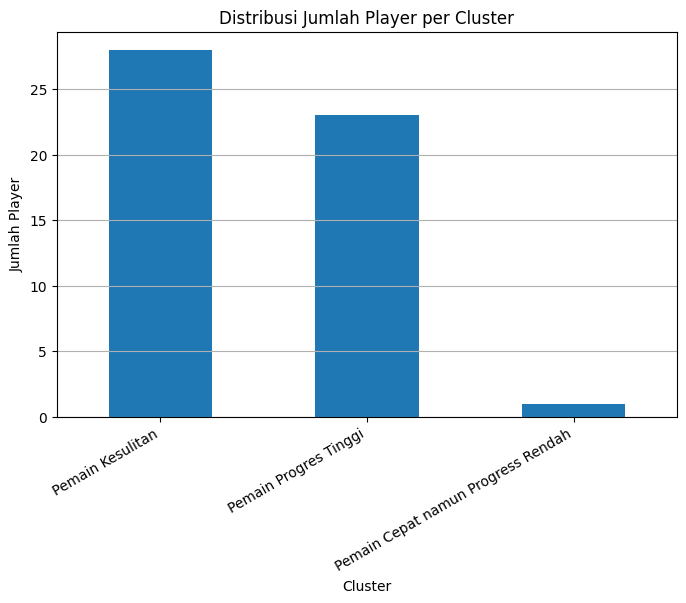

In [26]:
cluster_counts = df["cluster_name"].value_counts()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind="bar")
plt.title("Distribusi Jumlah Player per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Player")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.show()

<Figure size 900x500 with 0 Axes>

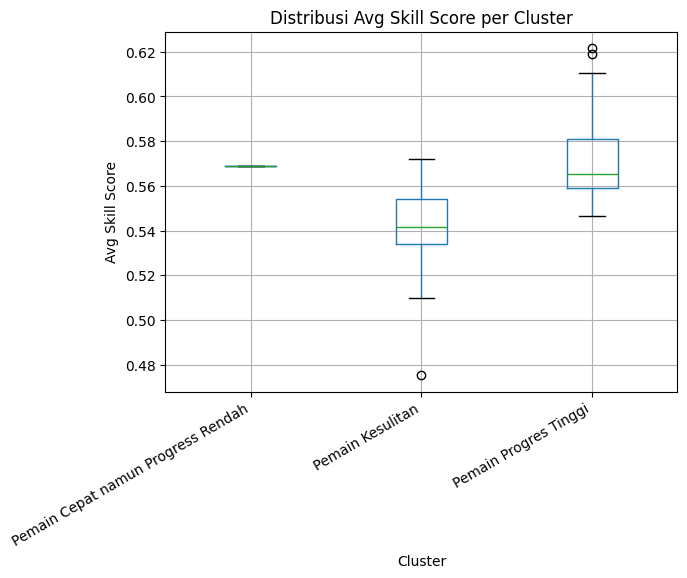

In [27]:
plt.figure(figsize=(9, 5))

df.boxplot(
    column="avg_skill_score",
    by="cluster_name",
    grid=True
)

plt.title("Distribusi Avg Skill Score per Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Avg Skill Score")
plt.xticks(rotation=30, ha="right")
plt.show()

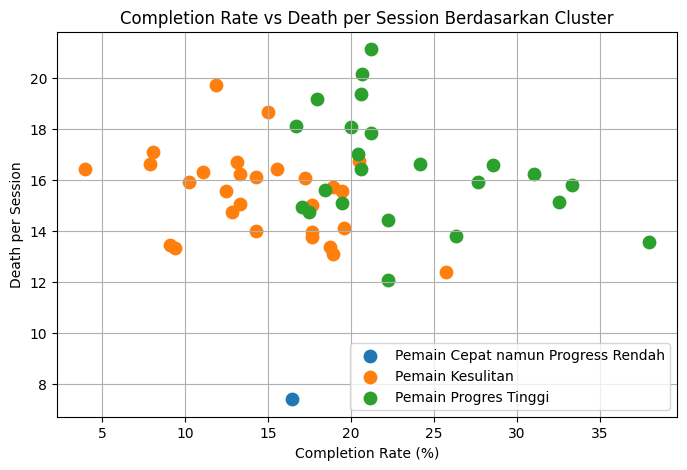

In [28]:
plt.figure(figsize=(8, 5))

for cluster_name in df["cluster_name"].unique():
    subset = df[df["cluster_name"] == cluster_name]
    plt.scatter(
        subset["completion_rate"],
        subset["death_per_session"],
        label=cluster_name,
        s=80
    )

plt.title("Completion Rate vs Death per Session Berdasarkan Cluster")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Death per Session")
plt.legend()
plt.grid(True)
plt.show()

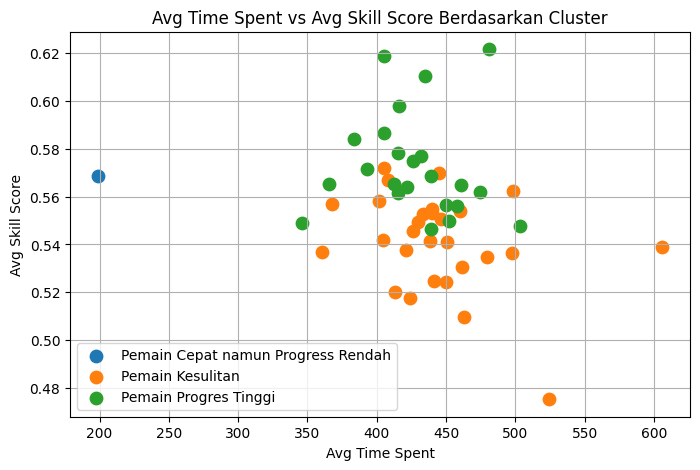

In [29]:
plt.figure(figsize=(8, 5))

for cluster_name in df["cluster_name"].unique():
    subset = df[df["cluster_name"] == cluster_name]
    plt.scatter(
        subset["avg_time_spent"],
        subset["avg_skill_score"],
        label=cluster_name,
        s=80
    )

plt.title("Avg Time Spent vs Avg Skill Score Berdasarkan Cluster")
plt.xlabel("Avg Time Spent")
plt.ylabel("Avg Skill Score")
plt.legend()
plt.grid(True)
plt.show()

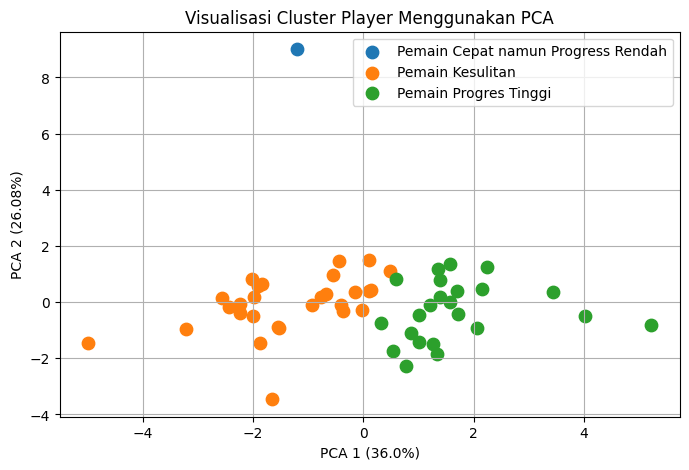

Explained variance PCA 1: 36.0 %
Explained variance PCA 2: 26.08 %
Total explained variance: 62.09 %


In [30]:
from sklearn.decomposition import PCA

# PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Masukkan hasil PCA ke dataframe
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]

# Hitung explained variance
pca1_var = round(pca.explained_variance_ratio_[0] * 100, 2)
pca2_var = round(pca.explained_variance_ratio_[1] * 100, 2)
total_var = round(sum(pca.explained_variance_ratio_) * 100, 2)

# Visualisasi PCA
plt.figure(figsize=(8, 5))

for cluster_name in df["cluster_name"].unique():
    subset = df[df["cluster_name"] == cluster_name]
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        label=cluster_name,
        s=80
    )

plt.title("Visualisasi Cluster Player Menggunakan PCA")
plt.xlabel(f"PCA 1 ({pca1_var}%)")
plt.ylabel(f"PCA 2 ({pca2_var}%)")
plt.legend()
plt.grid(True)
plt.show()

# Tampilkan informasi explained variance
print("Explained variance PCA 1:", pca1_var, "%")
print("Explained variance PCA 2:", pca2_var, "%")
print("Total explained variance:", total_var, "%")

In [31]:
cluster_summary_final = df.groupby("cluster_name")[features].mean().round(4)
cluster_summary_final["jumlah_player"] = df["cluster_name"].value_counts()

cluster_summary_final

,total_sessions,completion_rate,avg_time_spent,avg_death_count,avg_max_checkpoint,avg_progress_score,avg_survival_score,avg_efficiency_score,avg_skill_score,best_skill_score,jumlah_player
cluster_name,,,,,,,,,,,
Pemain Cepat namun Progress Rendah,85.0000,16.4700,199.0200,7.4000,2.6000,0.5200,0.6407,0.6413,0.5688,1.0000,1
Pemain Kesulitan,37.5714,14.5725,444.1325,15.4311,2.9375,0.5875,0.5946,0.4567,0.5414,0.8716,28
Pemain Progres Tinggi,35.5217,23.3787,427.3970,16.4265,3.2843,0.6566,0.5580,0.5151,0.5729,0.8749,23


In [32]:
df.to_csv("hasil_kmeans_player_lengkap.csv", index=False)